In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running on: {device}")

def get_dataloaders(dataset_name, batch_size=64):
    """
    Loads the specified dataset, applies transformations and
    returns the train and test loaders.
    """
    dataset_name = dataset_name.upper()

    # Choose transformations
    if dataset_name == 'MNIST':
        # MNIST: 1 channel
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)) # Átlag és szórás 1 csatornára
        ])
        DatasetClass = torchvision.datasets.MNIST

    elif dataset_name == 'CIFAR10':
        # CIFAR10: 3 channel (RGB)
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Átlag és szórás 3 csatornára
        ])
        DatasetClass = torchvision.datasets.CIFAR10

    elif dataset_name == 'CIFAR100':
        # CIFAR100: 3 channel (RGB)
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Átlag és szórás 3 csatornára
        ])
        DatasetClass = torchvision.datasets.CIFAR100

    else:
        raise ValueError(f"Wrong database: {dataset_name}")

    dataset_train = DatasetClass(
        root='./data',
        train=True,
        download=True,
        transform=transform
    )

    dataset_test = DatasetClass(
        root='./data',
        train=False,
        download=True,
        transform=transform
    )

    # Set up loades
    train_loader = torch.utils.data.DataLoader(
        dataset_train,
        batch_size=batch_size,
        shuffle=True
    )

    test_loader = torch.utils.data.DataLoader(
        dataset_test,
        batch_size=batch_size,
        shuffle=False
    )

    images, labels = next(iter(train_loader))
    print(f"[{dataset_name}] Batch size: Images {images.shape}, Labels {labels.shape}")

    return train_loader, test_loader

Running on: cuda


In [3]:
def train_and_evaluate(model, trainloader, testloader, dataset_name, epochs=5,
                       learning_rate=0.01):
    """
    Trains the model, evaluates it on test data, plots learning curve.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    # SGD optimazation with momentum
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9,
                          weight_decay=1e-5)
    # OneCycleLR changes learning rate dynamically, so it learns faster
    scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=learning_rate,
                                              steps_per_epoch=len(trainloader), epochs=epochs)

    # results
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}


    for epoch in range(epochs):
        # train
        model.train()
        running_train_loss = 0.0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad() # delete gradients (make them zero)

            # model returns (result, feature_list) we only need the result
            outputs = model(inputs)[0]

            loss = criterion(outputs, labels)
            loss.backward() # Backprop
            optimizer.step() # update weights
            scheduler.step() # update learning rate

            running_train_loss += loss.item()

        # avarage loss epoch
        epoch_train_loss = running_train_loss / len(trainloader)
        history['train_loss'].append(epoch_train_loss)

        # validation
        model.eval()
        running_val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad(): # without gradient so its faster
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)[0]
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()

                # choose the one with the biggest probability
                predicted = outputs.argmax(dim=1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = running_val_loss / len(testloader)
        epoch_val_acc = 100 * correct / total

        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {epoch_train_loss:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} | "
              f"Val Accuracy: {epoch_val_acc:.2f}%")

    # plot results
    plt.figure(figsize=(12, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs+1), history['train_loss'], label='Tanítási Hiba (Train)', color='blue', marker='o')
    plt.plot(range(1, epochs+1), history['val_loss'], label='Teszt Hiba (Val)', color='red', marker='x')
    plt.title(f'{dataset_name} - Hiba (Loss) görbe')
    plt.xlabel('Epoch')
    plt.ylabel('CrossEntropy Hiba')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs+1), history['val_acc'], label='Teszt Pontosság (Accuracy)', color='green', marker='s')
    plt.title(f'{dataset_name} - Pontosság')
    plt.xlabel('Epoch')
    plt.ylabel('Százalék (%)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    return history

In [4]:
class PureCNN(nn.Module):
    def __init__(self, in_channels, num_classes, num_conv_layers):
        super().__init__()

        conv_layers_count = num_conv_layers - 2
        layers = []
        current_channels = in_channels
        filters = [64, 128, 256, 512]

        layers_per_block = conv_layers_count // 4
        if layers_per_block == 0:
          layers_per_block = 1

        layer_id = 0
        for f in filters:
            for _ in range(layers_per_block):
                if layer_id < conv_layers_count:
                    layers.append(nn.Conv2d(current_channels, f, kernel_size=3, padding=1))
                    layers.append(nn.BatchNorm2d(f))
                    layers.append(nn.ReLU(inplace=True))
                    current_channels = f
                    layer_id += 1

            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))

            if layer_id >= conv_layers_count:
                break

        self.features = nn.ModuleList(layers)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Linear(current_channels, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        features_list = []

        for layer in self.features:
            x = layer(x)

            if isinstance(layer, (nn.Conv2d, nn.MaxPool2d)):
                features_list.append(x)

        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)

        return x, features_list

def create_model_for_dataset(dataset_name):
    if dataset_name.upper() == 'MNIST':
        return PureCNN(in_channels=1, num_classes=10, num_conv_layers=8)
    elif dataset_name.upper() == 'CIFAR10':
        return PureCNN(in_channels=3, num_classes=10, num_conv_layers=14)
    elif dataset_name.upper() == 'CIFAR100':
        return PureCNN(in_channels=3, num_classes=100, num_conv_layers=20)
    else:
        raise ValueError("Ismeretlen adatbázis!")

Processing: MNIST


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 507kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.54MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.79MB/s]


[MNIST] Batch size: Images torch.Size([64, 1, 28, 28]), Labels torch.Size([64])
Epoch 01/5 | Train Loss: 0.1689 | Val Loss: 0.0978 | Val Accuracy: 97.06%
Epoch 02/5 | Train Loss: 0.0487 | Val Loss: 0.0387 | Val Accuracy: 98.80%
Epoch 03/5 | Train Loss: 0.0235 | Val Loss: 0.0311 | Val Accuracy: 99.12%
Epoch 04/5 | Train Loss: 0.0126 | Val Loss: 0.0171 | Val Accuracy: 99.45%
Epoch 05/5 | Train Loss: 0.0053 | Val Loss: 0.0162 | Val Accuracy: 99.52%


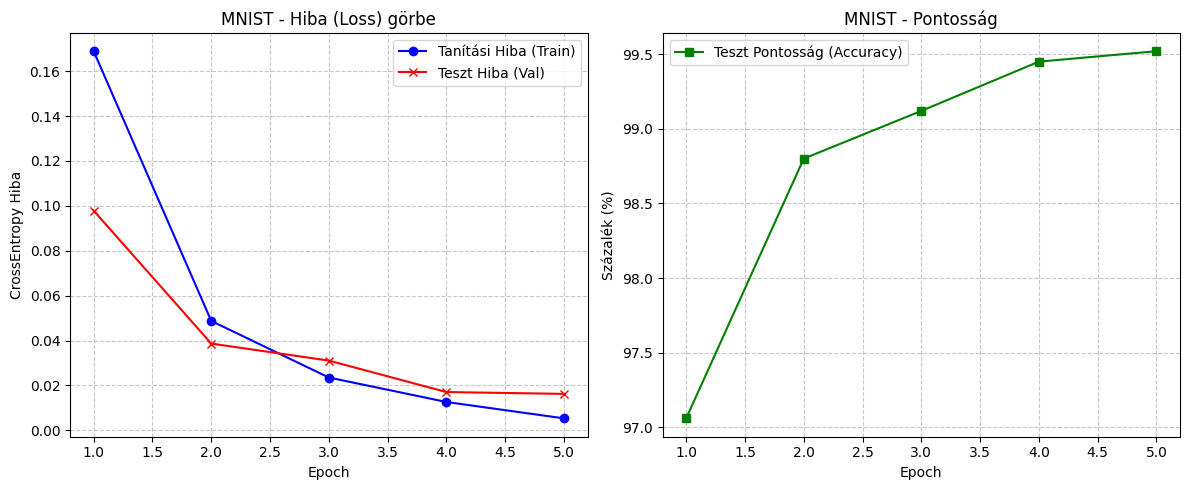

Processing: CIFAR10


100%|██████████| 170M/170M [00:05<00:00, 29.7MB/s]


[CIFAR10] Batch size: Images torch.Size([64, 3, 32, 32]), Labels torch.Size([64])
Epoch 01/10 | Train Loss: 1.3567 | Val Loss: 1.2824 | Val Accuracy: 57.02%
Epoch 02/10 | Train Loss: 0.9596 | Val Loss: 0.9372 | Val Accuracy: 70.02%
Epoch 03/10 | Train Loss: 0.7501 | Val Loss: 0.6879 | Val Accuracy: 77.79%
Epoch 04/10 | Train Loss: 0.5840 | Val Loss: 0.6002 | Val Accuracy: 80.40%


In [ ]:
databases = ['MNIST', 'CIFAR10', 'CIFAR100']
epochs = {'MNIST': 5, 'CIFAR10': 10, 'CIFAR100': 10}

for db_nev in databases:
    print(f"Processing: {db_nev}")

    # 1. Load data
    train_loader, test_loader = get_dataloaders(db_nev, batch_size=64)

    # 2. create network
    model = create_model_for_dataset(db_nev)

    # 3. training and plot results
    current_epoch = epochs[db_nev]
    eredmenyek = train_and_evaluate(
        model=model,
        trainloader=train_loader,
        testloader=test_loader,
        dataset_name=db_nev,
        epochs=current_epoch,
        learning_rate=0.05
    )